# Validation of the window with integral constraints

In [1]:
import logging

import os

import numpy as np
import matplotlib.pyplot as plt

import lsstypes

logger = logging.getLogger('FIT PNG')

plt.style.use('ec_style.mplstyle')   

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem
# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
def propose_fiducial(kmin=1e-3, kmax=8e-2, region='GCcomb'):
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}

    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
      
    return propose_fiducial


def load_data(data_dir, mocks_dir, tracer, fiducial=propose_fiducial(), window_extra='RIC+AMR',
              kpivot=[1e-2, 2e-2], nrebin=[2,2], weight_type_mocks=None):
    """ 
    """
    import lsstypes 

    from tools import read_data, rebin_data

    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    if weight_type_mocks is None: weight_type_mocks = 'default-noimsys-fkp-oqe_reshuffle' if window_extra == '' else 'default-fkp-oqe'
    logger.info(f"Reading data for tracer {tracer} with weight type {weight_type_mocks} and window_extra={window_extra}.")

    kwargs = fiducial[short_tracer]

    pk, window, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, window_extra=window_extra,
                                        weight_type_mocks=weight_type_mocks, **kwargs)
    pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, kpivot=kpivot, nrebin=nrebin, **kwargs)
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')

    zeff = {}
    zeff[0] = window.observable.get(0).attrs['zeff']
    try: 
        zeff[2] = window.observable.get(2).attrs['zeff']
    except KeyError:
        pass

    return pk, window, cov, zeff, mock

In [3]:
#root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

# Where the data are:
data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
# Where the mocks are:
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

+------------------------+--------+-------+
| chi2 = 1.91 / (42 - 4) |  best  | error |
+------------------------+--------+-------+
|      QSO_ell0.b1       | 3.067  | 0.048 |
|    QSO_ell0.sigmas     |  5.89  | 0.36  |
|      QSO_ell0.sn0      | -0.053 | 0.048 |
|        fnl_loc         |  0.7   |  5.5  |
|      QSO_ell2.b1       |  2.9   |       |
|    QSO_ell2.sigmas     |  5.9   |       |
+------------------------+--------+-------+


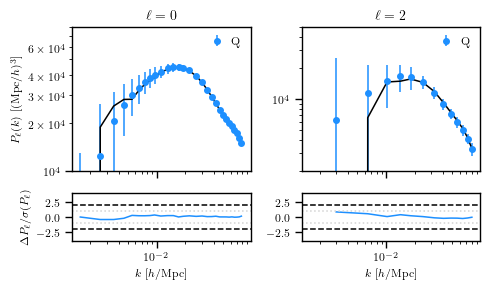

In [4]:
region = 'GCcomb'

pk, window, _, zeff, mocks = load_data(data_dir, mocks_dir, 'QSO', propose_fiducial(region=region), window_extra='RIC+AMR')
zeffs = {'QSOxQSO': zeff}

window_ini = lsstypes.read(data_dir + f'/window_mesh2_spectrum_poles_QSO_z0.8-3.5_{region}_weight-default-fkp-oqe_RIC+AMR.h5')
window_ini = window_ini.at.observable.match(pk)

from tools import get_observable_and_likelihood, run_profiler, plot_observables

obs, lik = get_observable_and_likelihood(lsstypes.mean(mocks), window_ini, mocks, 'QSO', zeffs, engine='camb', fix_fnl=False, nickname='QSO') 
prof = run_profiler(lik)
print(prof.profiles.to_stats(tablefmt="pretty"))
plot_observables({'QSO': obs}, figsize=(5,3), show=True, fn_output='fig/validation_window_0.png')

For now the theory is looking very weird ... Let's check what is going on!


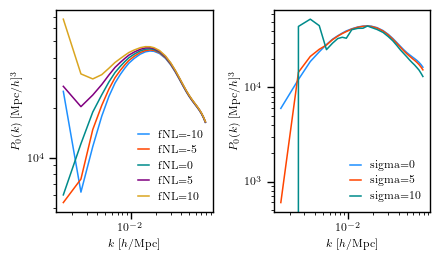

Ok ... something happens when sigma increases... Looks like a small effect propagated into large scales --> This looks like a window problem!


In [5]:
print("For now the theory is looking very weird ... Let's check what is going on!")

from desilike.base import compile, params

plt.figure(figsize=(4.5, 2.7))

test = obs[0].clone()
pipe_test = compile(test)
values = {par.name: par._value for par in params(test)}

plt.subplot(121)
for fnl in [-10, -5, 0, 5, 10]:
    values.update({'fnl_loc': fnl, 'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': 0})
    pipe_test(values)
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'fNL={fnl}')
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')

plt.subplot(122)
for sigma in [0, 5, 10]:
    values.update({'fnl_loc': 0, 'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': sigma})
    pipe_test(values)
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'sigma={sigma}')
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')
plt.tight_layout()
plt.savefig('fig/validation_window_1.png', dpi=400)
plt.show()

print('Ok ... something happens when sigma increases... Looks like a small effect propagated into large scales --> This looks like a window problem!')

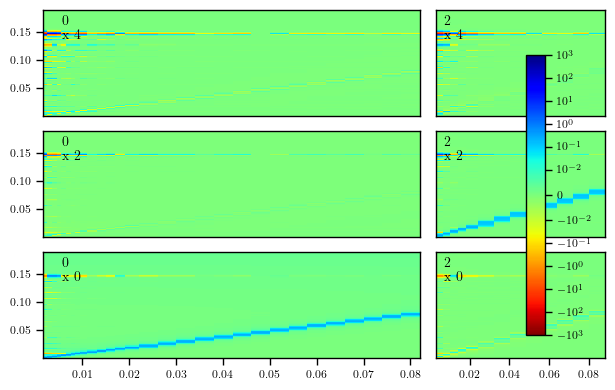

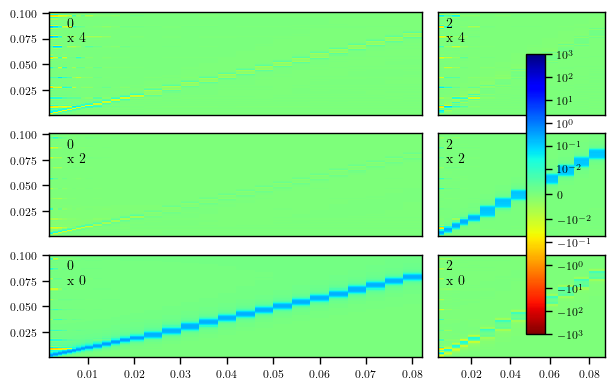

In [6]:
import matplotlib.colors as mcolors
norm_sym = mcolors.SymLogNorm(linthresh=1e-2, linscale=1.0, vmin=-1e3, vmax=1e3)

import warnings
warnings.filterwarnings('ignore', message='.*tight_layout.*')

_ = window_ini.plot(norm=norm_sym, figsize=(5, 4))
plt.savefig('fig/validation_window_2.png', dpi=400)
plt.show()

window_test = window_ini.at.theory.select(k=(1e-4,0.1))

_ = window_test.plot(norm=norm_sym, figsize=(5, 4))
plt.savefig('fig/validation_window_3.png', dpi=400)
plt.show()

*From conversation with Domitille and Arnaud.*

There are "two issues" on this plot:
* The large artifact/spike: it appears right around that k_Nyquist value; in the FM windows before rebinning, the last bin contains modes above k_Nyquist — hence the failure. The key is that the theoretical k_max (input theory) exceeds the Nyquist wavenumber of the observation, which is problematic.
    * Plan: add something in desi-clustering to enforce a theory k_max matched to the Nyquist of the mesh used for the window — this should fully fix the large spike issue.
* The small artifacts: these are rebinning artifacts, expected to not add physically meaningful features in the power spectrum.
    * Plan: change the rebinning kernel to be more visually uniform on the matrix --> but no significant change to the spectrum is expected.

+------------------------+-------+-------+
| chi2 = 0.98 / (42 - 4) | best  | error |
+------------------------+-------+-------+
|      QSO_ell0.b1       | 3.069 | 0.046 |
|    QSO_ell0.sigmas     | 6.07  | 0.40  |
|      QSO_ell0.sn0      | 0.016 | 0.053 |
|        fnl_loc         | -0.2  |  4.3  |
|      QSO_ell2.b1       |  2.9  |       |
|    QSO_ell2.sigmas     |  6.1  |       |
+------------------------+-------+-------+


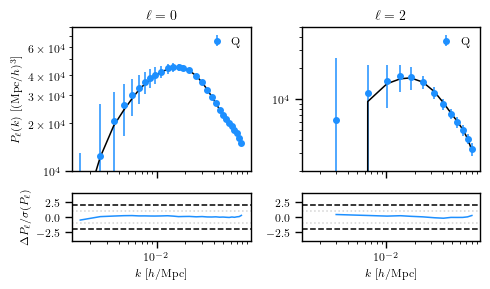

In [7]:
from tools import get_observable_and_likelihood, run_profiler, plot_observables

obs, lik = get_observable_and_likelihood(lsstypes.mean(mocks), window_test, mocks, 'QSO', zeffs, engine='camb', fix_fnl=False, nickname='QSO') 
prof = run_profiler(lik)
print(prof.profiles.to_stats(tablefmt="pretty"))
plot_observables({'QSO': obs}, figsize=(5,3), show=True, fn_output='fig/validation_window_4.png')

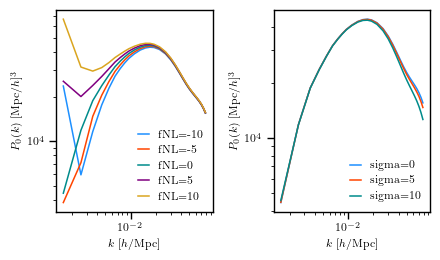

In [8]:
from desilike.base import compile, params

plt.figure(figsize=(4.5, 2.7))

test = obs[0].clone()
pipe_test = compile(test)
values = {par.name: par._value for par in params(test)}

plt.subplot(121)
for fnl in [-10, -5, 0, 5, 10]:
    values.update({'fnl_loc': fnl, 'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': 0})
    pipe_test(values)
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'fNL={fnl}')
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')

plt.subplot(122)
for sigma in [0, 5, 10]:
    values.update({'fnl_loc': 0, 'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': sigma})
    pipe_test(values)
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'sigma={sigma}')
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')
plt.tight_layout()
plt.show()

Victory ! (Obviously, these input modes have to be removed by default -> will be done in the futur).

If we want to go at super large scales i.e. almost at the limit of what we measure we need to increase the binning of k because we lack some power ..

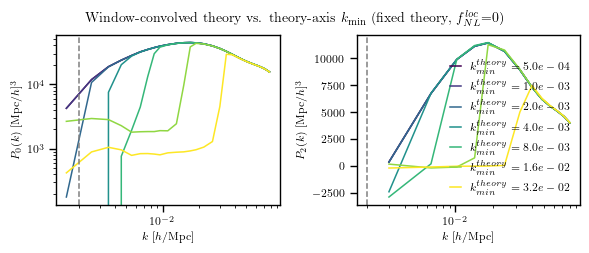

In [10]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from desilike.base import compile, params

# Fixed theory parameters (QSO), matching the cells above. Bump fnl_loc to amplify the
# large-scale PNG signal (~1/k^2) where the convolution kmin matters most.
fnl_fixed = 0.0
params0 = {'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': 0.0}
params2 = {'QSO_ell2.b1': 3.083, 'QSO_ell2.sigmas': 0.0}   # sn0 is fixed to 0 for ell=2

# Lower edge of the theory-axis selection to sweep (kmax fixed at 0.1). 5e-4 ~= native grid min.
kmins = np.array([5e-4, 1e-3, 2e-3, 4e-3, 8e-3, 1.6e-2, 3.2e-2])

norm = mcolors.LogNorm(vmin=kmins.min(), vmax=kmins.max())
cmap = cm.viridis

fig, axs = plt.subplots(1, 2, figsize=(6, 2.7))
for kmin_w in kmins:
    color = cmap(norm(kmin_w))
    window_k = window_ini.at.theory.select(k=(kmin_w, 0.1))
    obs_k, _ = get_observable_and_likelihood(lsstypes.mean(mocks), window_k, mocks, 'QSO', zeffs,
                                             engine='camb', fix_fnl=False, nickname='QSO')

    for obs_ell in obs_k:

        test = obs_ell.clone()
        pipe_test = compile(test)
        values = {par.name: par._value for par in params(test)}
        values.update({'fnl_loc': fnl_fixed})

        if 'ell2' in test.name:
            values.update(params2)
            pipe_test(values)
            axs[1].plot(test.data.get().k, test.flattheory, color=color, label=fr'$k^{{theory}}_{{min}}={kmin_w:.1e}$')
        else:
            values.update(params0)
            pipe_test(values)
            axs[0].loglog(test.data.get().k, test.flattheory, color=color)

axs[0].set_ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')
axs[1].set_ylabel(r'$P_2(k)$ [Mpc/$h$]$^3$')
for ax in axs:
    ax.set_xscale('log')
    ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    ax.axvline(2e-3, color='gray', linestyle='--')
axs[1].legend(loc='lower right')
fig.suptitle(f'Window-convolved theory vs. theory-axis $k_{{\\min}}$ (fixed theory, $f_{{NL}}^{{loc}}$={fnl_fixed:g})', y=0.92)
plt.show()

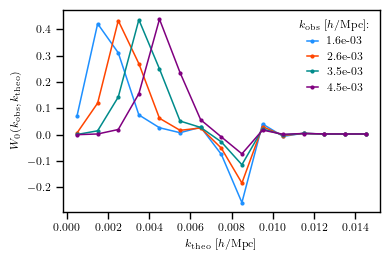

In [49]:
test = window_ini.at.theory.select(k=(1e-4,0.015))



ktheo = test.theory.get(0).k

kobs = test.observable.get(0).k

plt.figure(figsize=(4, 2.7))
for i in range(4):
    plt.plot(test.theory.get(0).k, test.value()[i,:ktheo.size], marker='.', label=f"{kobs[i]:2.1e}")

plt.xlabel(r'$k_{\rm theo}$ [$h$/Mpc]')
plt.ylabel(r'$W_0(k_{\rm obs}, k_{\rm theo})$')
plt.legend(title=r'$k_{\rm obs}$ [$h$/Mpc]:')
plt.tight_layout()
plt.savefig('fig/validation_window_5.png', dpi=400)
plt.show()

# Let's check the LRGs as well, to see if the problem is similar or not:

+------------------------+-------+-------+
| chi2 = 4.84 / (42 - 4) | best  | error |
+------------------------+-------+-------+
|      LRG_ell0.b1       | 2.157 | 0.025 |
|    LRG_ell0.sigmas     | 3.98  | 0.35  |
|      LRG_ell0.sn0      | 0.027 | 0.049 |
|        fnl_loc         | -3.0  |  4.1  |
|      LRG_ell2.b1       |  2.2  |       |
|    LRG_ell2.sigmas     |   4   |       |
+------------------------+-------+-------+


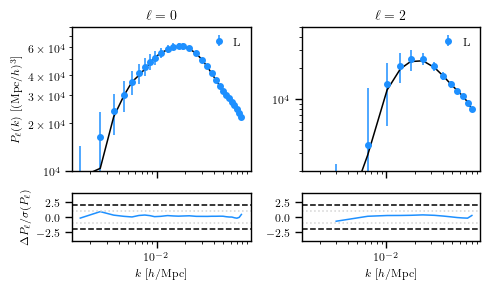

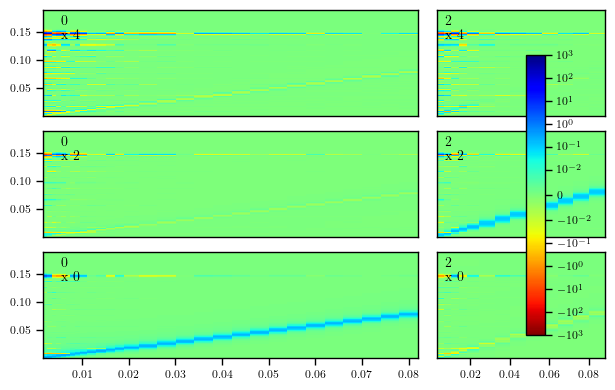

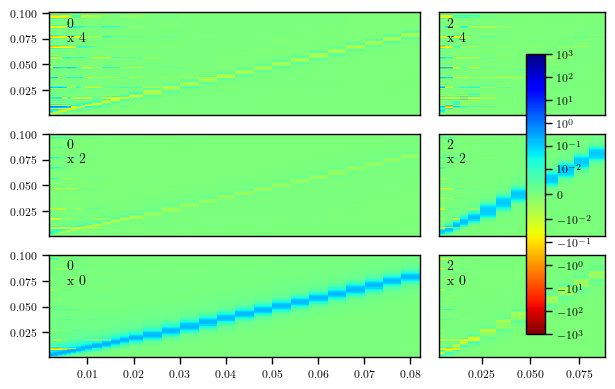

+------------------------+-------+-------+
| chi2 = 5.80 / (42 - 4) | best  | error |
+------------------------+-------+-------+
|      LRG_ell0.b1       | 2.151 | 0.026 |
|    LRG_ell0.sigmas     | 3.92  | 0.38  |
|      LRG_ell0.sn0      | 0.068 | 0.053 |
|        fnl_loc         | -3.3  |  3.5  |
|      LRG_ell2.b1       |  2.1  |       |
|    LRG_ell2.sigmas     |  3.9  |       |
+------------------------+-------+-------+


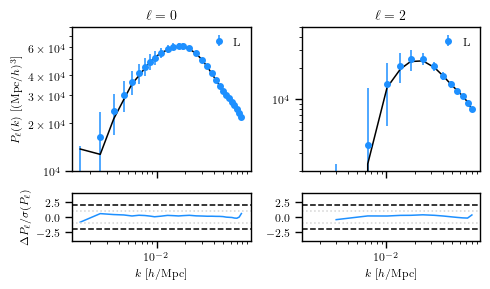

In [10]:
pk, window, _, zeff, mocks = load_data(data_dir, mocks_dir, 'LRG', propose_fiducial(), window_extra='RIC+AMR')
zeffs = {'LRGxLRG': zeff}

window_ini = lsstypes.read(data_dir + '/window_mesh2_spectrum_poles_LRG_z0.4-1.1_GCcomb_weight-default-fkp-oqe_RIC+AMR.h5')
window_ini = window_ini.at.observable.match(pk)

from tools import get_observable_and_likelihood, run_profiler, plot_observables

obs, lik = get_observable_and_likelihood(lsstypes.mean(mocks), window_ini, mocks, 'LRG', zeffs, engine='camb', fix_fnl=False, nickname='LRG') 
prof = run_profiler(lik)
print(prof.profiles.to_stats(tablefmt="pretty"))
plot_observables({'LRG': obs}, figsize=(5,3), show=True)

import matplotlib.colors as mcolors
norm_sym = mcolors.SymLogNorm(linthresh=1e-2, linscale=1.0, vmin=-1e3, vmax=1e3)
import warnings
warnings.filterwarnings('ignore', message='.*tight_layout.*')
_ = window_ini.plot(norm=norm_sym, figsize=(5, 4))
plt.show()

window_test = window_ini.at.theory.select(k=(1e-4,0.1))
_ = window_test.plot(norm=norm_sym, figsize=(5, 4))
plt.show()


obs, lik = get_observable_and_likelihood(lsstypes.mean(mocks), window_test, mocks, 'LRG', zeffs, engine='camb', fix_fnl=False, nickname='LRG') 
prof = run_profiler(lik)
print(prof.profiles.to_stats(tablefmt="pretty"))
plot_observables({'LRG': obs}, figsize=(5,3), show=True)

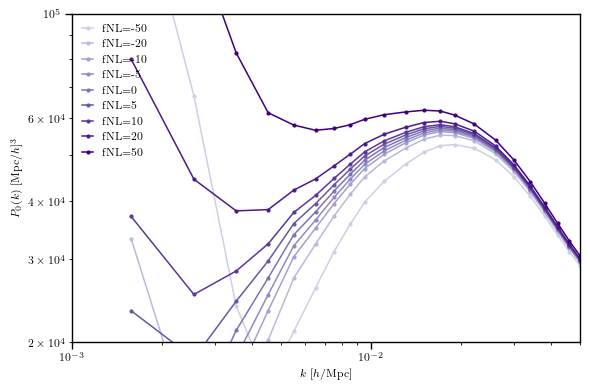

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from desilike.base import compile, params

plt.figure(figsize=(6, 4))

fnl_values = [-50, -20, -10, -5, 0, 5, 10, 20, 50]
colors = cm.Purples(np.linspace(0.3, 1.0, len(fnl_values)))  # avoid near-white at the low end

test = obs[0].clone()
pipe_test = compile(test)
base_params = {par.name: par._value for par in params(test)}
for fnl, color in zip(fnl_values, colors):
    values = dict(base_params)
    values.update({'fnl_loc': fnl, 'LRG_ell0.b1': 2.1, 'LRG_ell0.sn0': -0.065, 'LRG_ell0.sigmas': 0})
    pipe_test(values)
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'fNL={fnl}',
               marker='o', markersize=2, color=color)

plt.ylim([2e4, 1e5])
plt.xlim([1e-3, 5e-2])
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')
plt.tight_layout()
plt.show()

#